# Assignment 3

### Problem 1

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

a) load the data

In [7]:
df = pd.read_csv('data/mushrooms.csv')
df.head() 

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,NaN,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,NaN,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,NaN,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,NaN,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,NaN,o,e,n,a,g


b) correlation matrix

In [108]:
from sklearn.preprocessing import LabelEncoder
Encoder_Data = LabelEncoder()
# convert categorical features into numerical representations
for col in df.columns:
    df[col] = Encoder_Data.fit_transform(df[col])
df.head() 

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,0,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,0,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,0,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,0,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,0,1,0,3,0,1


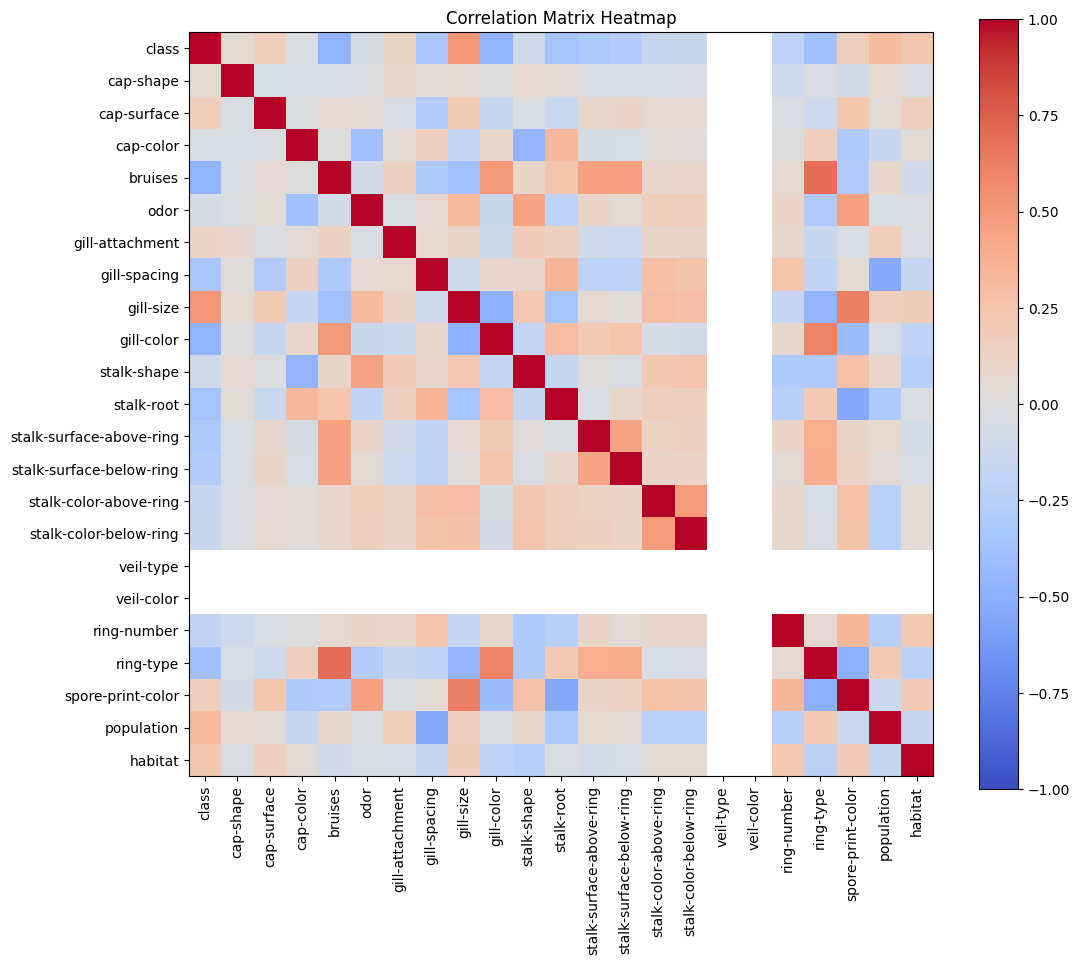

In [109]:
# compute correlation matrix
corr_matrix = df.corr()
# plot heatmap of correlation matrix
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.show()

c) histograms of the features

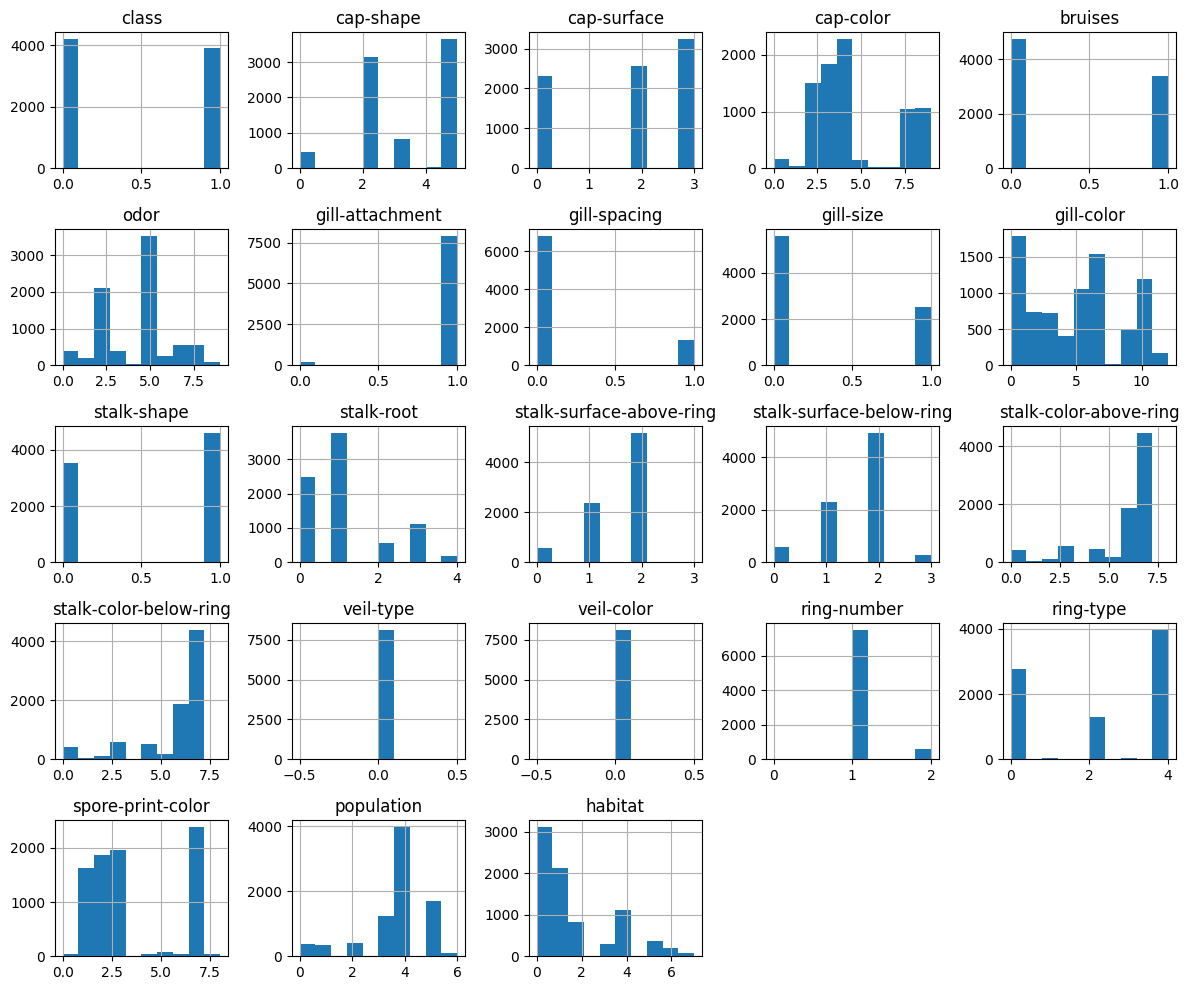

In [110]:
# histograms of the features
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Anomalies observed:
- veil-type has zero variance. Every mushroom has the same veil-type value. This feature provides no useful data, so it should be removed before analysis.
- veil-color has all empty entries. The colomn does not include any data, so it should be removed.
- stalk-root has entries with missing values, denoted as '?'. Solutions include dropping the entire column, or keeping '?' as a category.

d)Fix anomalies

In [30]:
df = pd.read_csv("data/mushrooms.csv")
# remove veil-type and veil-color
df = df.drop(columns=["veil-type", "veil-color"])

In [9]:
(df['stalk-root'] == '?').sum()
pd.crosstab(df['stalk-root'], df['class'])

class,e,p
stalk-root,,
?,756,1724
b,1924,1852
c,493,63
e,853,267
r,187,5


The features veil-type and veil-color are removed as they do not provide any useful data. \
Missing values are present in the stalk-root feature and are denoted as "?". In this case since these rows with stalk-root marked as "?" make up a sizable portion of the data, and the missing values are not random ("?" is strongly associated with poisonous), we leave the "?" in as its own category. \
There are no outliers since all features are categorical.

e) count plot of number of edible and poisonous mushrooms

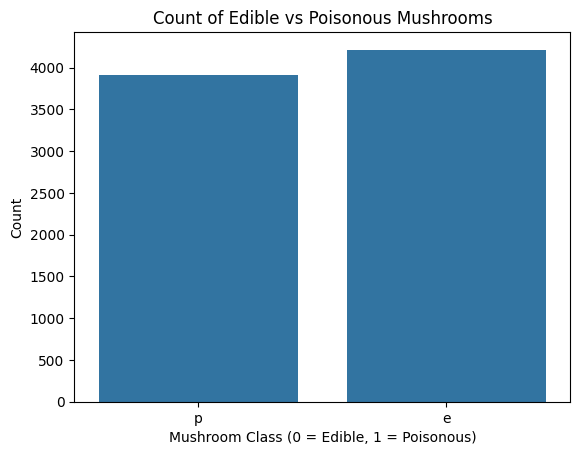

In [112]:
# count plot showing number of edible and posisonous mushrooms
sns.countplot(x='class', data=df)
plt.title('Count of Edible vs Poisonous Mushrooms')
plt.xlabel('Mushroom Class (0 = Edible, 1 = Poisonous)')
plt.ylabel('Count')
plt.show()

The dataset is balanced with respect to the class labels. The count of edible mushrooms is close to that of poisonous mushrooms.

f) Count plots of distribution of edible and poisonous mushrooms, conditioned on different features

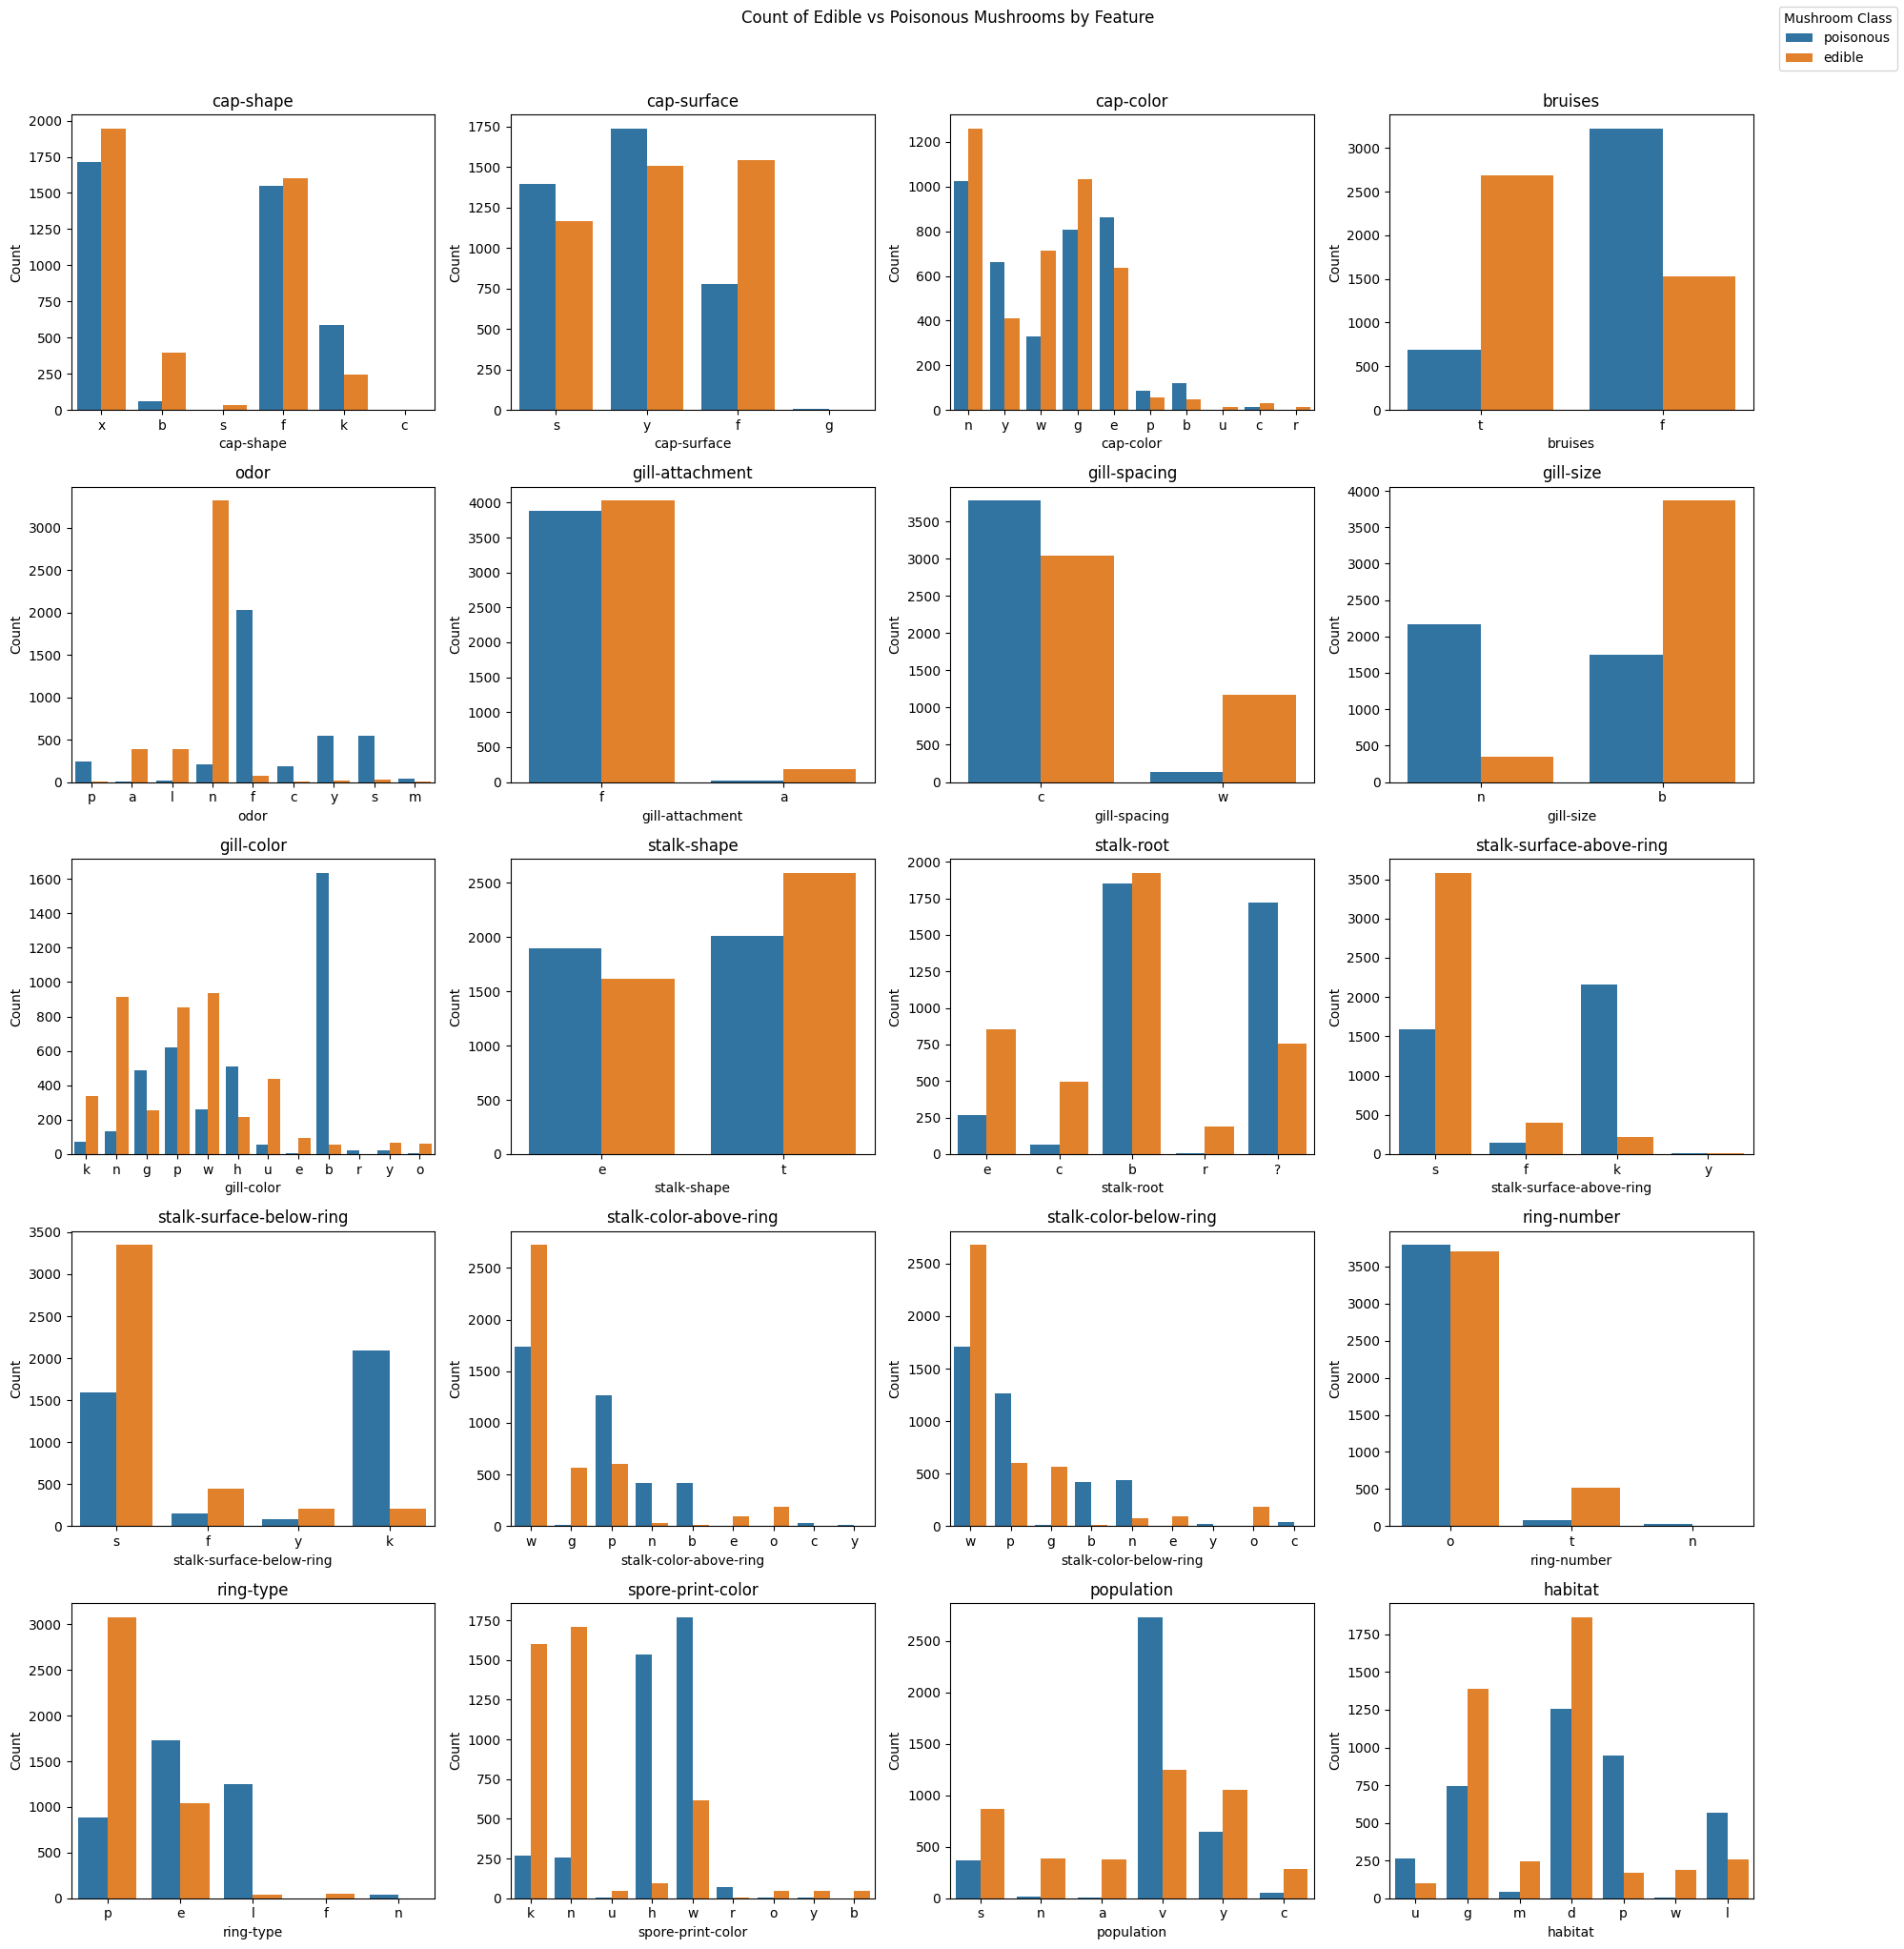

In [113]:
features = [col for col in df.columns if col != 'class']

n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, feature in enumerate(features):
    sns.countplot(x=feature, hue='class', data=df, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    if i == 0:
        handles, labels = axes[i].get_legend_handles_labels()
    axes[i].get_legend().remove()

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
    
labels = ['edible' if l == 'e' else 'poisonous' if l == 'p' else l for l in labels]
fig.legend(handles, labels, title='Mushroom Class', loc='upper right')
fig.suptitle('Count of Edible vs Poisonous Mushrooms by Feature', y=1.02)
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()


A pattern observed in most plots is the number of edible and poisonous mushroom are not balanced in each category of the features. This is desirable because we can use the features as predictors for mushroom class. 

Yes, the odor feature is very useful for classification since it is highly unbalanced in mushroom class and some categories can separate edible and poisonous almost perfectly.

The missing category in stalk-root would play an important role because it has around 700 more data points with poisonous class compared to edible. This is significant and will play a role in the models.

g) feature matrix X, target vector y

In [31]:
X = df.drop(columns=['class'])
y = df['class']

h) categorical to dummy (indicator) variables

In [32]:
from sklearn.preprocessing import LabelEncoder
X = pd.get_dummies(X)               # convert each categorical feature into multiple binary columns (one per category)
y = LabelEncoder().fit_transform(y) # transform to binary labels (0 and 1)

i) \
The Gini Index is a measurement of how impure a node is in a decision tree. It measures the probability of a random sample being incorrectly classified. It has values in range 0 to 0.5, were 0 is perfect purity and 0.5 is maximum impurity. The index is used to evaluate the quality of a split in a decision tree algorithm.
The formula for the Gini Index is given by:
$$
G = 1 - \sum_{k=1}^{K} p_k^2
$$


j) Decision tree classifier

Tree depth: 25
Number of leaves: 772
Number of nodes: 1543

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       839
           1       0.92      0.92      0.92       786

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625



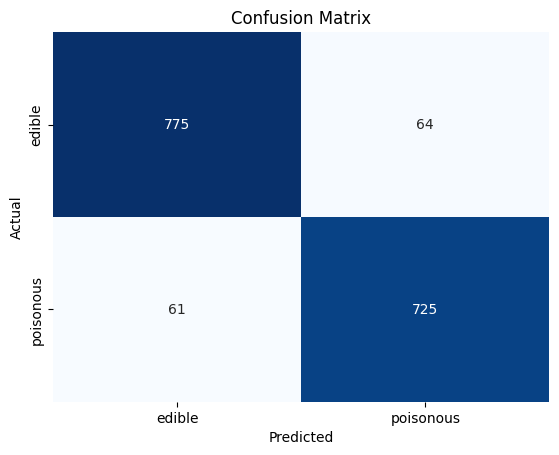

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

print(f"Tree depth: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")
print(f"Number of nodes: {clf.tree_.node_count}\n")

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['edible', 'poisonous'],
            yticklabels=['edible', 'poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

k) Vary minimum number of samples in each leaf

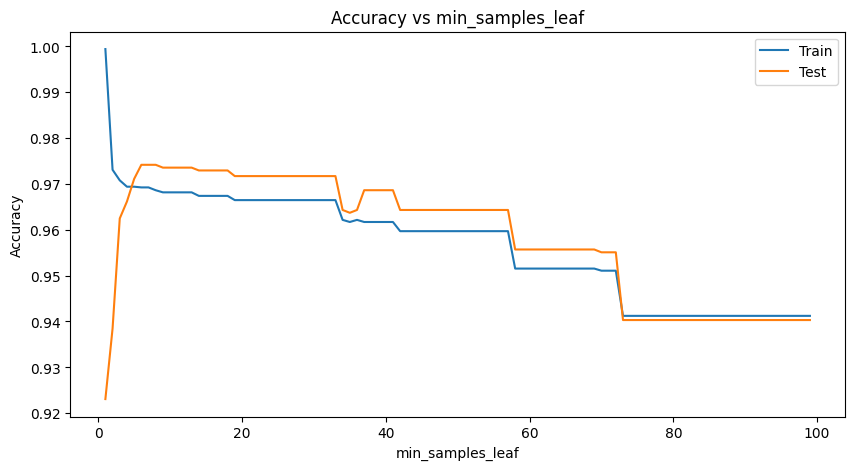

In [99]:
from sklearn.metrics import accuracy_score
min_samples_range = range(1, 100)
train_acc_k = []
test_acc_k = []

for m in min_samples_range:
    clf = DecisionTreeClassifier(criterion='gini', min_samples_leaf=m, random_state=42)
    clf.fit(X_train, y_train)
    train_acc_k.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc_k.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(min_samples_range, train_acc_k, label='Train')
plt.plot(min_samples_range, test_acc_k, label='Test')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_leaf')
plt.legend()
plt.show()

When min_samples_leaf = 1, the training accuracy is ~1 while the test accuracy is ~0.92, indicating overfitting. As min_samples_leaf increases, training accuracy drops sharply and then steadily, while test accuracy rises sharply initially past the training accuracy and then drops at a similar rate to the training accuracy. The test and training accuracies become constant and approximately equal (~0.94) past min_samples_leaf ~ 75, indicating underfitting. The optimal min_samples_leaf value is where the test accuracy is maximized.

l) Vary maximum tree depth

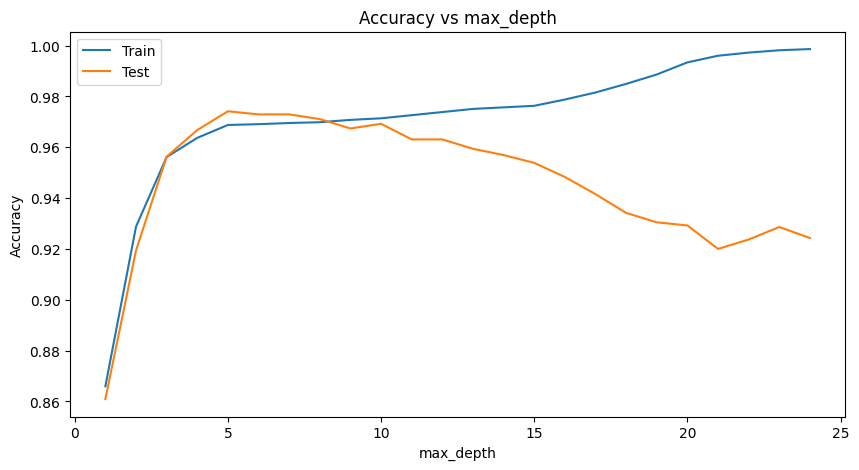

In [100]:
max_depth_range = range(1,25)
train_acc_l = []
test_acc_l = []

for d in max_depth_range:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc_l.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc_l.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(max_depth_range, train_acc_l, label='Train')
plt.plot(max_depth_range, test_acc_l, label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs max_depth')
plt.legend()
plt.show()

The training and test accuracies are approximately equal and increasing at low max_depth levels, indicating underfitting (tree lacks sufficient depth to capture patterns in the data). At max_depth ~5.0 both accuracies level off at ~0.97. Past max_depth ~7.5 the training accuracy increases and approaches 1 while the test accuracy decreases, indicating overfitting. This shows that the optimal tree depth is around 5, where test accuracy is maximized.

m) 2D-heatmap of model performance as a function of maximum tree depth and minimum samples per leaf.

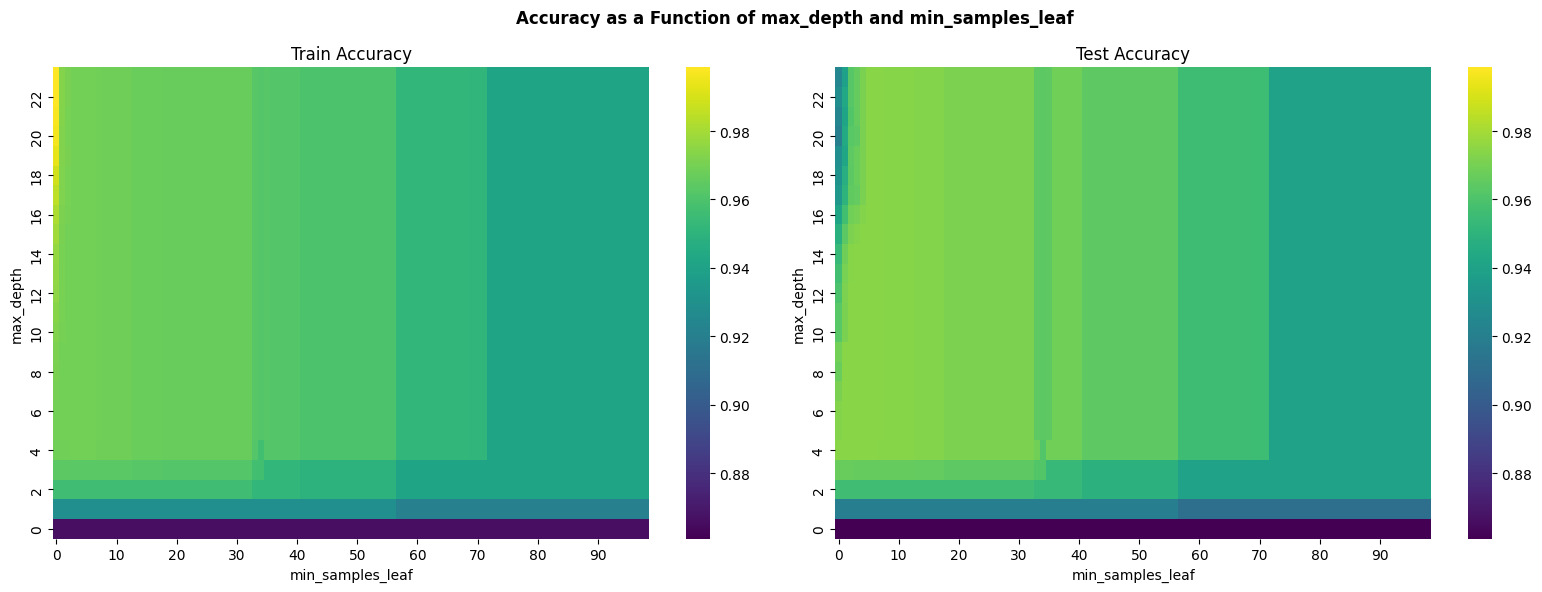

In [104]:
import numpy as np

depth_range = range(1, 25)
leaf_range = range(1, 100)

train_acc = np.zeros((len(depth_range), len(leaf_range)))
test_acc = np.zeros((len(depth_range), len(leaf_range)))

for i, d in enumerate(depth_range):
    for j, m in enumerate(leaf_range):
        clf = DecisionTreeClassifier(criterion='gini', max_depth=d, 
                                     min_samples_leaf=m, random_state=42)
        clf.fit(X_train, y_train)
        train_acc[i, j] = accuracy_score(y_train, clf.predict(X_train))
        test_acc[i, j] = accuracy_score(y_test, clf.predict(X_test))

vmin = min(train_acc.min(), test_acc.min())
vmax = max(train_acc.max(), test_acc.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(train_acc, ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=10, yticklabels=2)
axes[0].set_title('Train Accuracy')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(test_acc, ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=10, yticklabels=2)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')

axes[0].invert_yaxis()
axes[1].invert_yaxis()

plt.suptitle('Accuracy as a Function of max_depth and min_samples_leaf', fontweight='bold')
plt.tight_layout()
plt.show()

The two plots appear to be nearly identical, except for the top left region which shows underfitting.\
The accuracy appears to be highest where min_samples_leaf is between ~6-15, and max_depth is between 4-10. 

n) Visualized learned decision tree with limited depth

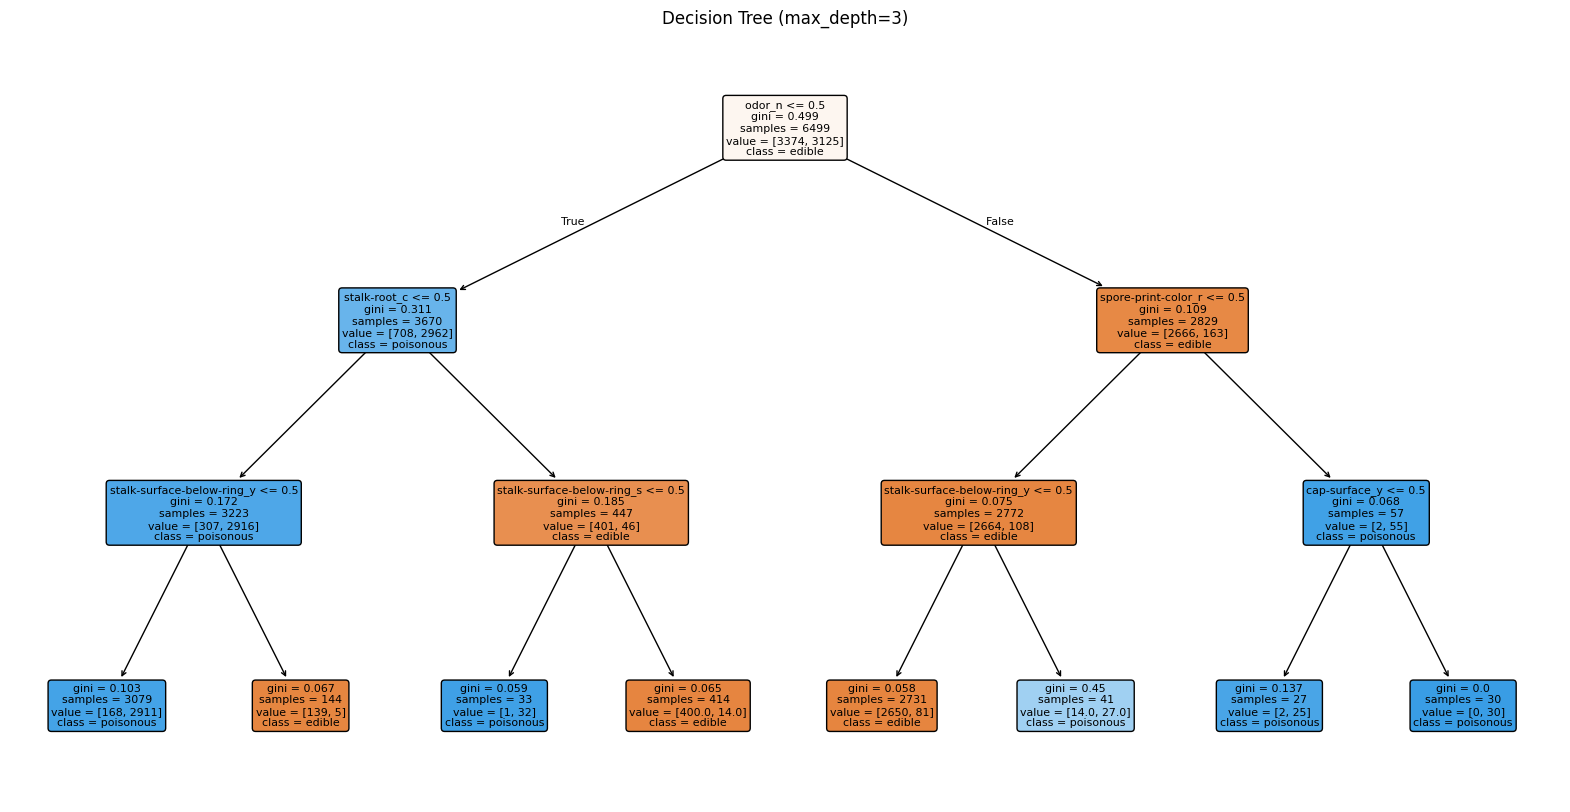

In [118]:
from sklearn.tree import plot_tree

clf_shallow = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_shallow.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(clf_shallow,
          feature_names=X.columns.tolist(),
          class_names=['edible', 'poisonous'],
          filled=True,
          rounded=True)
plt.title('Decision Tree (max_depth=3)')
plt.show()

The first split feature is odor_n. This shows that odor_n is the most important split feature. The secondary split features are stalk-root_c and spore-print-color_r.

o) Decision tree classifier with entropy splitting criterion

Entropy is another metric for evaluating a decision tree split. The lowest entropy 0 represents maximum purity and the largest value 1 represents maximum impurity / uncertainty. Tree splits maximizes information gain, which is the entropy of the parent minus the entopy of the children after the split. The formula for entropy is given by:
$$H(X) = - \sum_{i} p(x_i) \ln p(x_i)$$

Tree depth: 31
Number of leaves: 793
Number of nodes: 1585

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       839
           1       0.92      0.91      0.92       786

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625



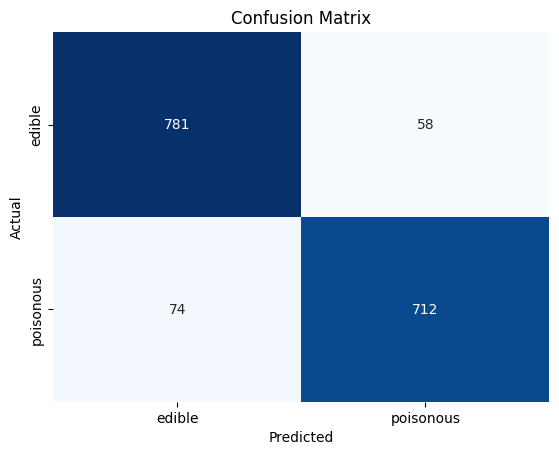

In [119]:
# classification report and confusion matrix 
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

print(f"Tree depth: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")
print(f"Number of nodes: {clf.tree_.node_count}\n")

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['edible', 'poisonous'],
            yticklabels=['edible', 'poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

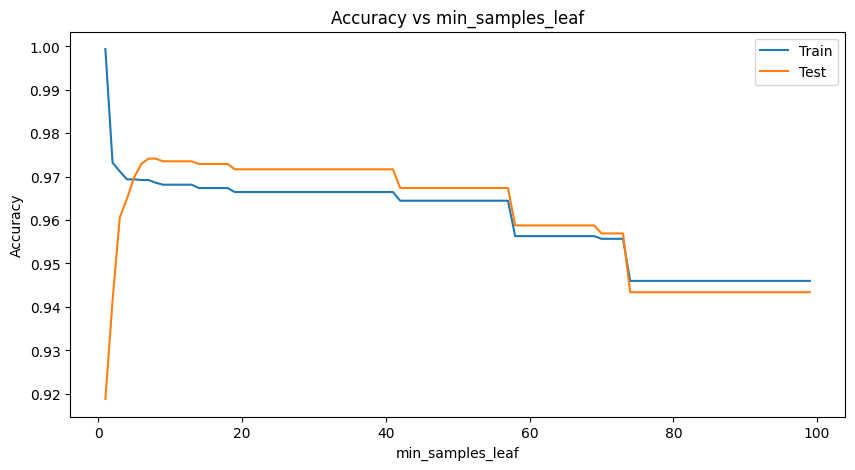

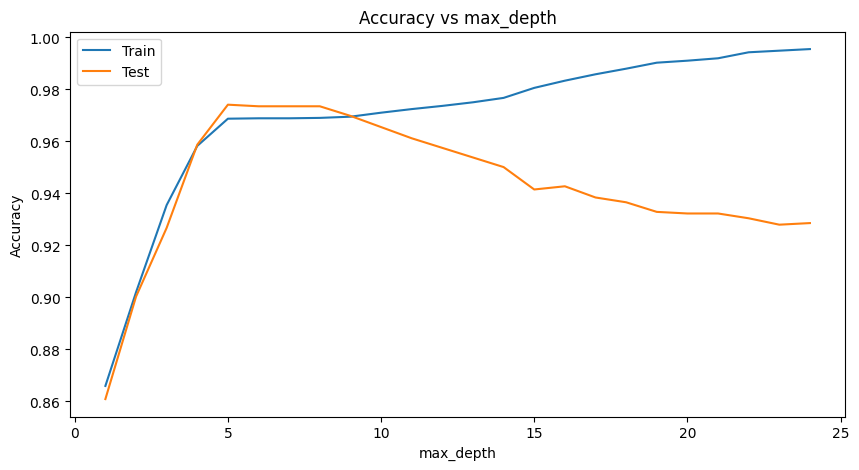

In [121]:
# vary min_samples_leaf, max_tree_depth
from sklearn.metrics import accuracy_score
min_samples_range = range(1, 100)
train_acc_k = []
test_acc_k = []

for m in min_samples_range:
    clf = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=m, random_state=42)
    clf.fit(X_train, y_train)
    train_acc_k.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc_k.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(min_samples_range, train_acc_k, label='Train')
plt.plot(min_samples_range, test_acc_k, label='Test')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_leaf')
plt.legend()
plt.show()

max_depth_range = range(1,25)
train_acc_l = []
test_acc_l = []

for d in max_depth_range:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc_l.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc_l.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(max_depth_range, train_acc_l, label='Train')
plt.plot(max_depth_range, test_acc_l, label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs max_depth')
plt.legend()
plt.show()

The accuracy graphs appear similar to the ones using the Gini index. The suitable values can be identified as min_samples_leaf in (8-20) and max depth in (5-7).

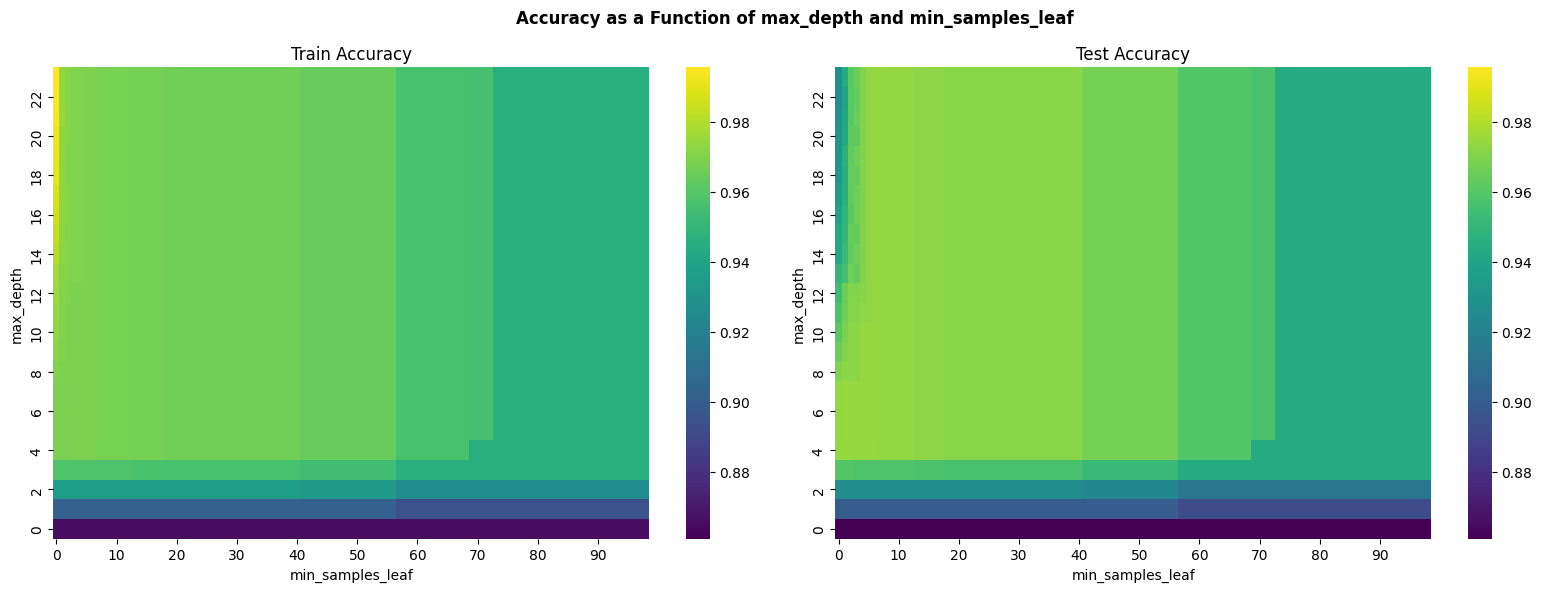

In [122]:
# 2D heatmap
depth_range = range(1, 25)
leaf_range = range(1, 100)

train_acc = np.zeros((len(depth_range), len(leaf_range)))
test_acc = np.zeros((len(depth_range), len(leaf_range)))

for i, d in enumerate(depth_range):
    for j, m in enumerate(leaf_range):
        clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, 
                                     min_samples_leaf=m, random_state=42)
        clf.fit(X_train, y_train)
        train_acc[i, j] = accuracy_score(y_train, clf.predict(X_train))
        test_acc[i, j] = accuracy_score(y_test, clf.predict(X_test))

vmin = min(train_acc.min(), test_acc.min())
vmax = max(train_acc.max(), test_acc.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(train_acc, ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=10, yticklabels=2)
axes[0].set_title('Train Accuracy')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(test_acc, ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=10, yticklabels=2)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')

axes[0].invert_yaxis()
axes[1].invert_yaxis()

plt.suptitle('Accuracy as a Function of max_depth and min_samples_leaf', fontweight='bold')
plt.tight_layout()
plt.show()

The accuracy graphs appear similar to the ones using the Gini index. The suitable values can be identified as min_samples_leaf in (8-20) and max depth in (5-7). Both graphs appear similar except for the top left region where there is underfitting.

p) Random Forest

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       839
           1       0.97      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

[[819  20]
 [ 23 763]]


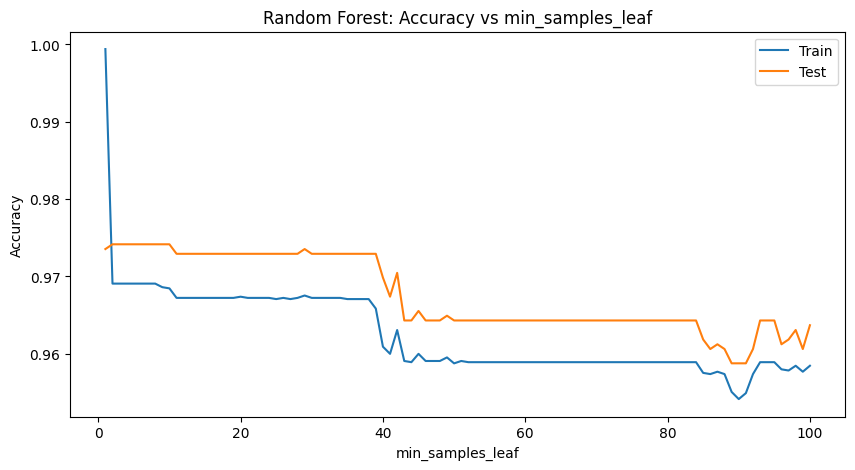

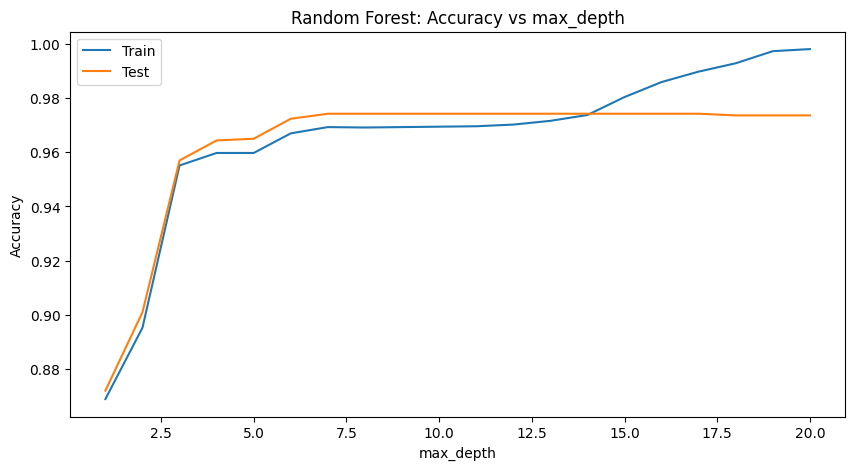

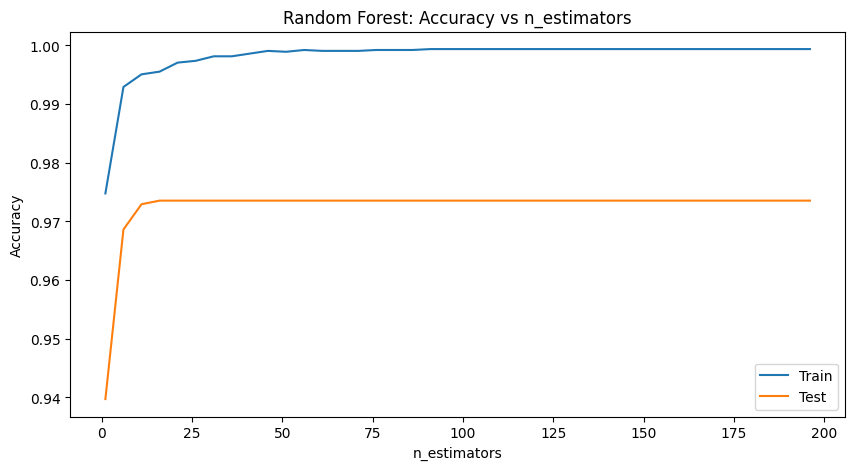

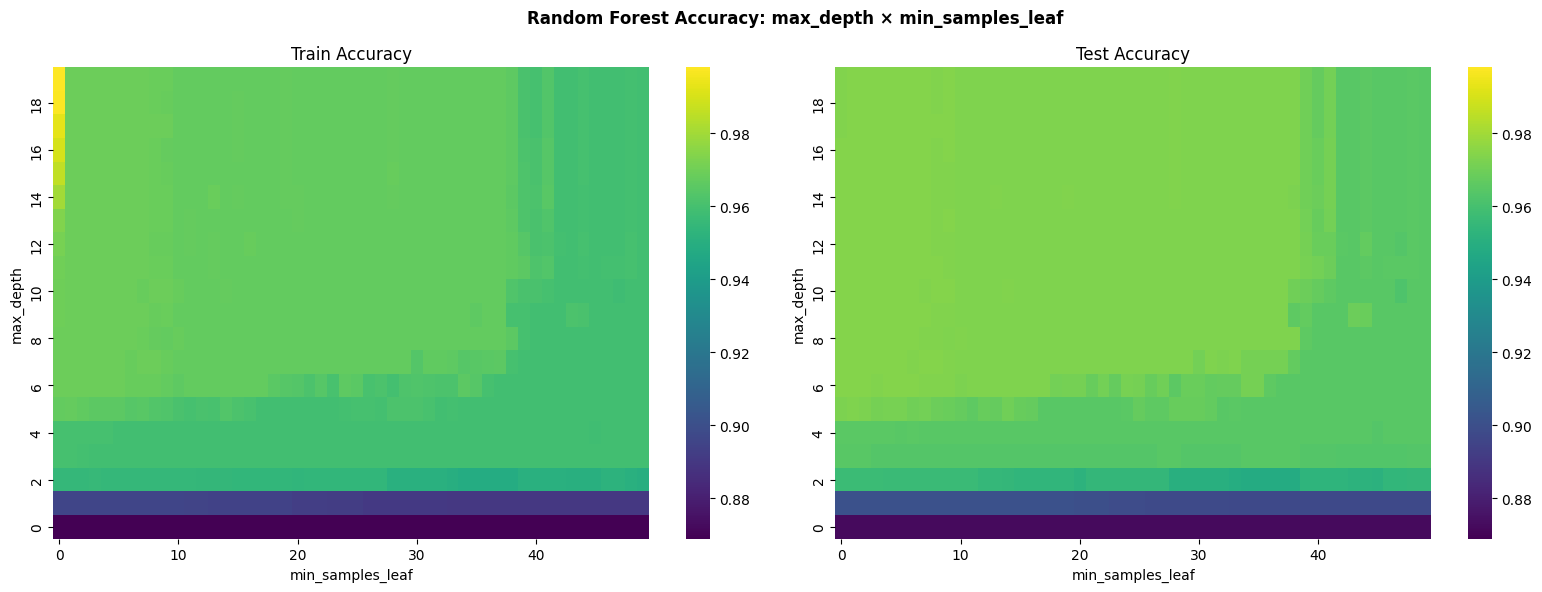

In [123]:
from sklearn.ensemble import RandomForestClassifier

# basic random forest with default parameters
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# min_samples_leaf
train_acc_k, test_acc_k = [], []
for m in range(1, 101):
    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=m, random_state=42)
    rf.fit(X_train, y_train)
    train_acc_k.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc_k.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), train_acc_k, label='Train')
plt.plot(range(1, 101), test_acc_k, label='Test')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs min_samples_leaf')
plt.legend()
plt.show()

# max_depth
train_acc_l, test_acc_l = [], []
for d in range(1, 21):
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    train_acc_l.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc_l.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), train_acc_l, label='Train')
plt.plot(range(1, 21), test_acc_l, label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs max_depth')
plt.legend()
plt.show()

# n_estimators
train_acc_n, test_acc_n = [], []
n_range = range(1, 201, 5)
for n in n_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_acc_n.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc_n.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_range, train_acc_n, label='Train')
plt.plot(n_range, test_acc_n, label='Test')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs n_estimators')
plt.legend()
plt.show()

# 2D heatmap
depth_range = range(1, 21)
leaf_range = range(1, 51)

train_acc = np.zeros((len(depth_range), len(leaf_range)))
test_acc = np.zeros((len(depth_range), len(leaf_range)))

for i, d in enumerate(depth_range):
    for j, m in enumerate(leaf_range):
        rf = RandomForestClassifier(n_estimators=100, max_depth=d,
                                    min_samples_leaf=m, random_state=42)
        rf.fit(X_train, y_train)
        train_acc[i, j] = accuracy_score(y_train, rf.predict(X_train))
        test_acc[i, j] = accuracy_score(y_test, rf.predict(X_test))

vmin = min(train_acc.min(), test_acc.min())
vmax = max(train_acc.max(), test_acc.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(train_acc, ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=10, yticklabels=2)
axes[0].set_title('Train Accuracy')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(test_acc, ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=10, yticklabels=2)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.suptitle('Random Forest Accuracy: max_depth × min_samples_leaf', fontweight='bold')
plt.tight_layout()
plt.show()


q) 
The most important features 

r) Precision and recall as a function of number of trees and max tree depth

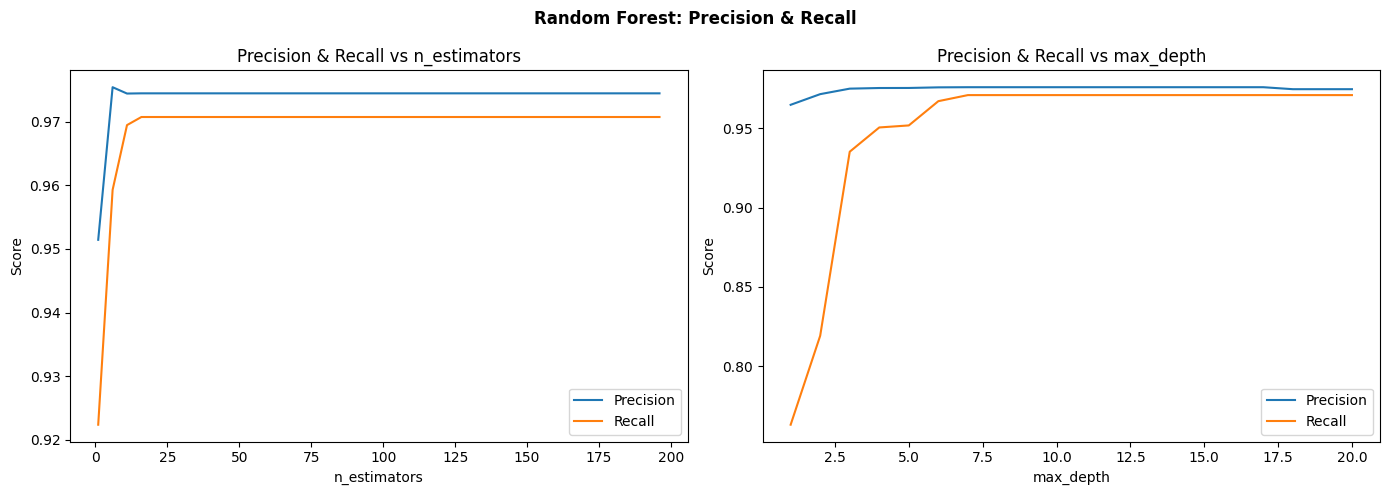

In [124]:
from sklearn.metrics import precision_score, recall_score

# precision and recall vs n_estimators
precision_n, recall_n = [], []
for n in n_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    precision_n.append(precision_score(y_test, y_pred))
    recall_n.append(recall_score(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(n_range, precision_n, label='Precision')
axes[0].plot(n_range, recall_n, label='Recall')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision & Recall vs n_estimators')
axes[0].legend()

# precision and recall vs max_depth
precision_d, recall_d = [], []
for d in range(1, 21):
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    precision_d.append(precision_score(y_test, y_pred))
    recall_d.append(recall_score(y_test, y_pred))

axes[1].plot(range(1, 21), precision_d, label='Precision')
axes[1].plot(range(1, 21), recall_d, label='Recall')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs max_depth')
axes[1].legend()

plt.suptitle('Random Forest: Precision & Recall', fontweight='bold')
plt.tight_layout()
plt.show()

The graph shows for n_estimators, an increase in n_estimators lead to an initial sharp increase in both precision and recall before they both become stable. The precision and recall remain constant after the initial spike, with precision higher than recall.
For max_depth, the graph shows a slower increase initially for recall, and precision initially is already near the value it settles at. The two curves approachh a constant value and are very close in value, with recall being slightly less than precision.

s) SVM

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       839
           1       0.98      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625



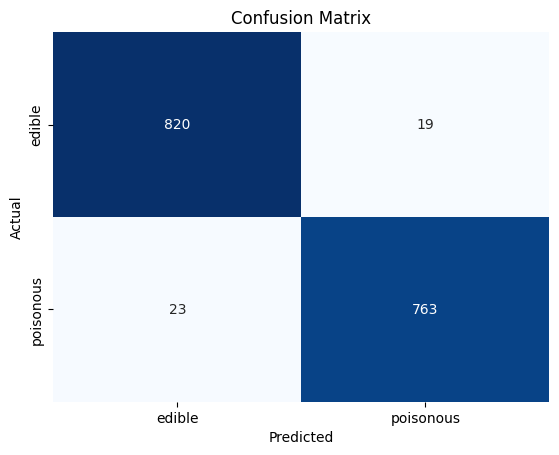

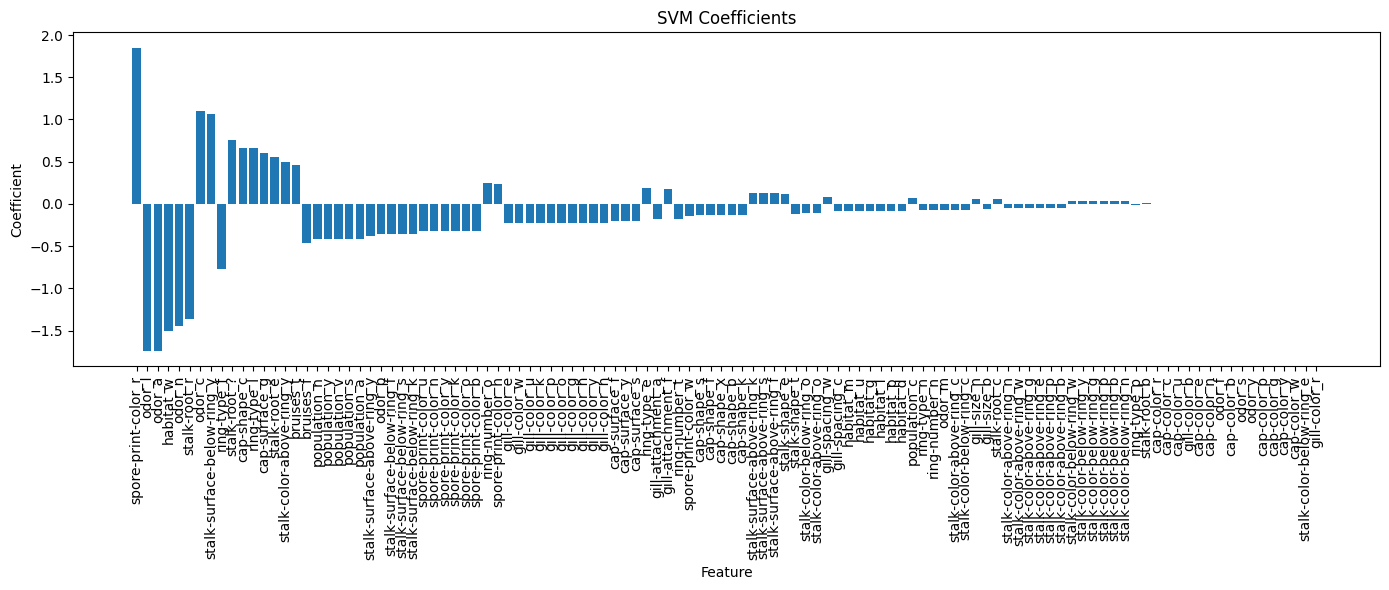

In [18]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['edible', 'poisonous'],
            yticklabels=['edible', 'poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# visualize coefficients
coefficients = svm.coef_[0]
feature_names = X.columns.tolist()

plt.figure(figsize=(14, 6))
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
plt.bar(range(len(coefficients)), coefficients[sorted_idx])
plt.xticks(range(len(coefficients)), [feature_names[i] for i in sorted_idx], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('SVM Coefficients')
plt.tight_layout()
plt.show()

The features relied on the most for classification are spore=print-color_r, odor_l, and odor_a. Both SVM and decision tree have spore_print_color_r as one of the top 3 features, but odur_l and odur_a are not in the top 3 features for decision tree.

t) SGD classifier

In [17]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='hinge', random_state=42)
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)

print(classification_report(y_test, y_pred_sgd))
print(confusion_matrix(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       839
           1       0.98      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

[[820  19]
 [ 23 763]]


u) Standardization

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# retrain SGD with scaled data
sgd_scaled = SGDClassifier(loss='hinge', random_state=42)
sgd_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = sgd_scaled.predict(X_test_scaled)

print("Without scaling:")
print(classification_report(y_test, y_pred_sgd))

print("With scaling:")
print(classification_report(y_test, y_pred_scaled))

Without scaling:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       839
           1       0.98      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

With scaling:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       839
           1       0.98      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625



Data normalization or standardization has no effect here because the transformed features are binary values so they are already on a uniform scale.
If we use the label encoding instead, scaling does not have much of an impact becasue the integer values assigned to the categories are arbitrary. 
Normalization or standardization is only effective when features are continuous and have different ranges.

v) class imbalance

The mushroom dataset is already approximately balanced, so class imbalance does not impact the performance of the models significantly.\
In an imbalanced dataset the model would be more biased towards the majority class.\
Methods to address class imbalance without removing data include:
- class weighting: assigning a higher penalty for misclassifying the minority class
- oversampling: generate new minority class samples using SMOTE

w) visualize learned SGD coefficients

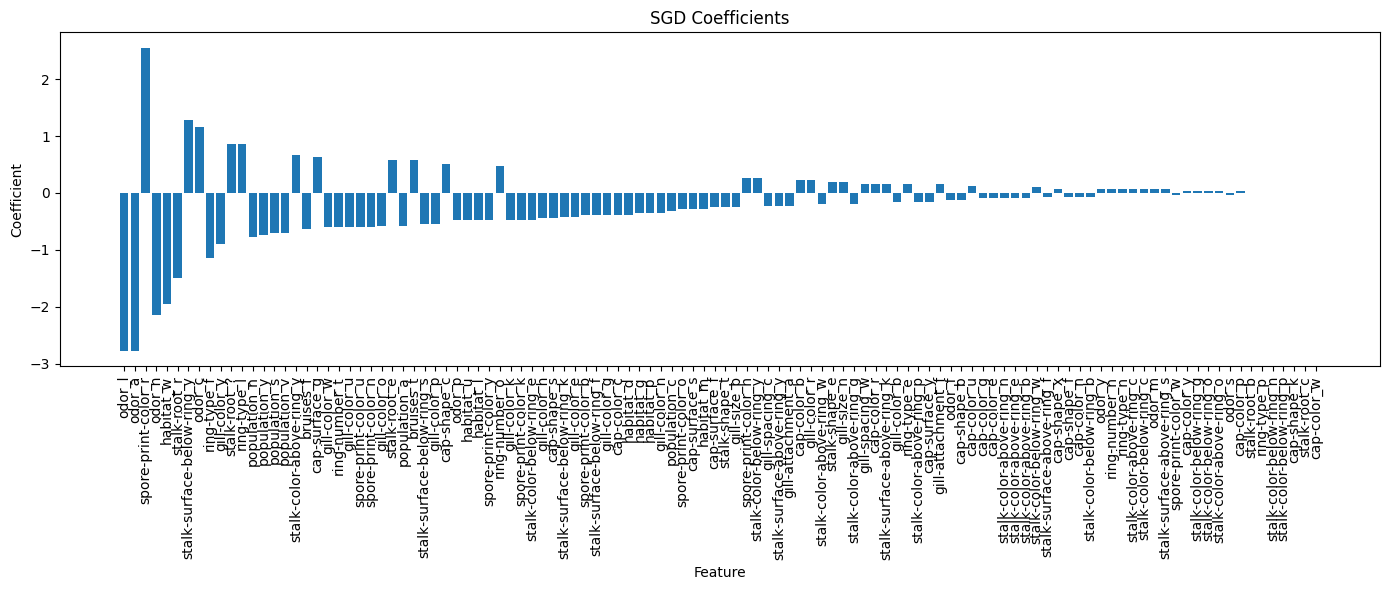

In [135]:
# visualize SGD coefficients
sgd = SGDClassifier(loss='hinge', random_state=42)
sgd.fit(X_train, y_train)

coefficients = sgd.coef_[0]
feature_names = X.columns.tolist()

sorted_idx = np.argsort(np.abs(coefficients))[::-1]

plt.figure(figsize=(14, 6))
plt.bar(range(len(coefficients)), coefficients[sorted_idx])
plt.xticks(range(len(coefficients)), [feature_names[i] for i in sorted_idx], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('SGD Coefficients')
plt.tight_layout()
plt.show()

The features relied on the most for classification are spore=print-color_r, odor_l, and odor_a. Both SVM and decision tree have spore_print_color_r as one of the top 3 features, but odur_l and odur_a are not in the top 3 features for decision tree.

x) Logistic Regression

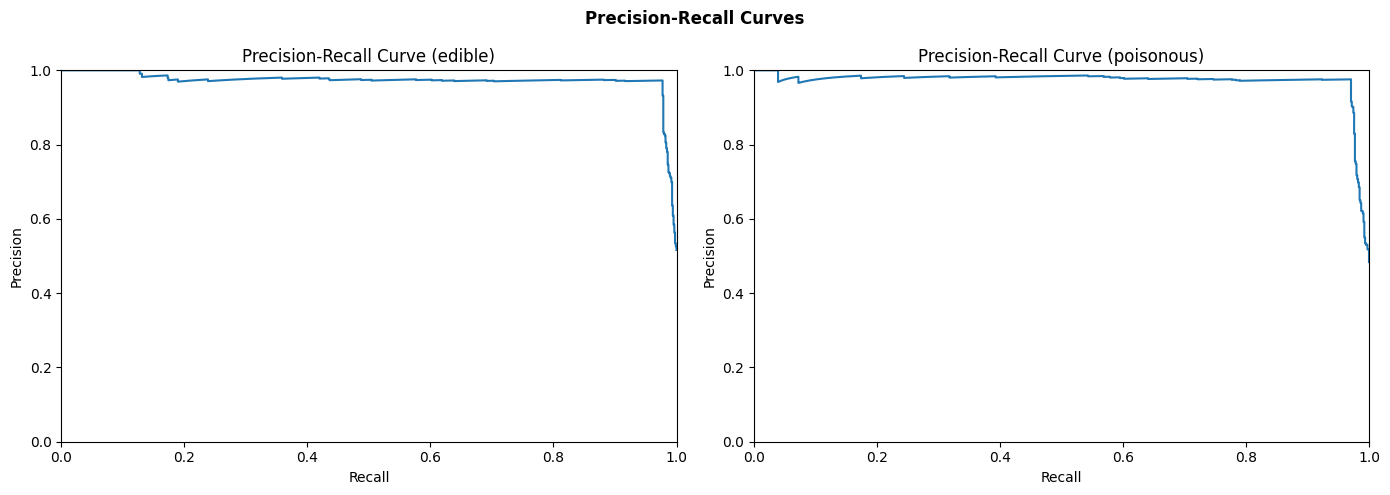

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# train logistic regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# get prediction probabilities
y_proba = lr.predict_proba(X_test)

# precision-recall curve for each class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, class_name in enumerate(['edible', 'poisonous']):
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba[:, i], 
                                                            pos_label=i)
    axes[i].plot(recall, precision)
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_title(f'Precision-Recall Curve ({class_name})')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])

plt.suptitle('Precision-Recall Curves', fontweight='bold')
plt.tight_layout()
plt.show()

y)
In both classes the precision-recall curve maintains high precision across the recall values and then drops off sharply when recall is close to 1. This means the curves have AOC close to 1. This means that the model is not sensitive to the choice of decision threshold since precision stays relatively stable as threshold is varied, and it is highly confident.

If the curves were sensitive then that would mean that small changes in the threshold would cause large changes in precision or recall, showing a lack of confidence of the model.

The difference between the curves for both classes are minimal. Differences can occur due to class imbalance, feature separability, and class overlap in feature space.

z) ROC curves

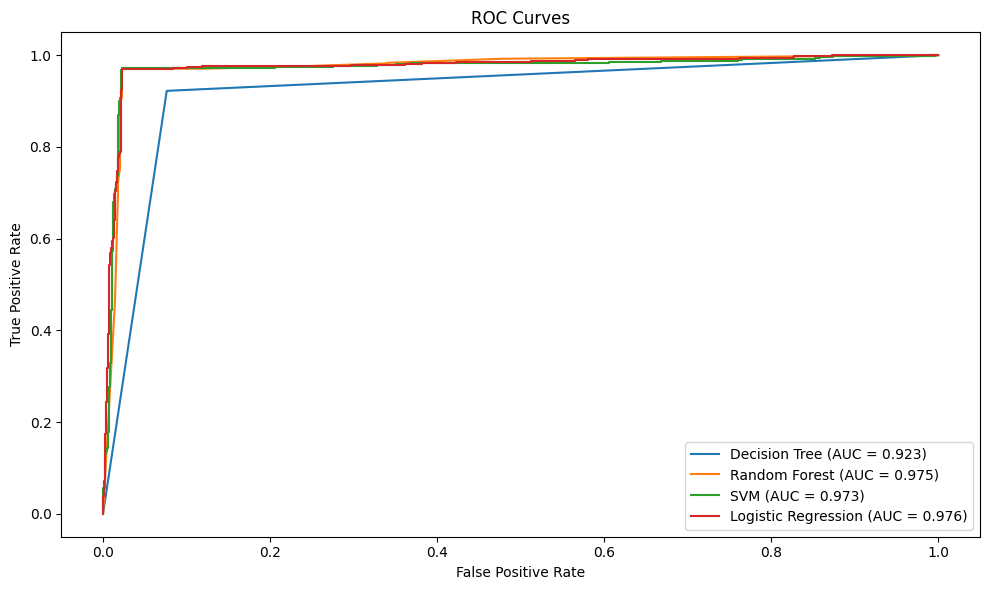

In [34]:
# train multiple models
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

plt.figure(figsize=(10, 6))

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# random classifier baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

The random forest, SVM, and logistic regression models performed similarly, with similar AUC around 0.975, with logistic regression having the highest AUC at 0.976. The decision tree model performed worse than the 3 models at AUC = 0.923. 
The random forest model outperforming a single decision tree shows that averaging many trees reduces overfitting from a single tree.
The decision tree's low AUC shows that it is sensitive to the training samples and can overfit.
The high performance of SVM and logistic regression suggest that the classes (after transforming to indicator variables) are linearly separable. 

end)

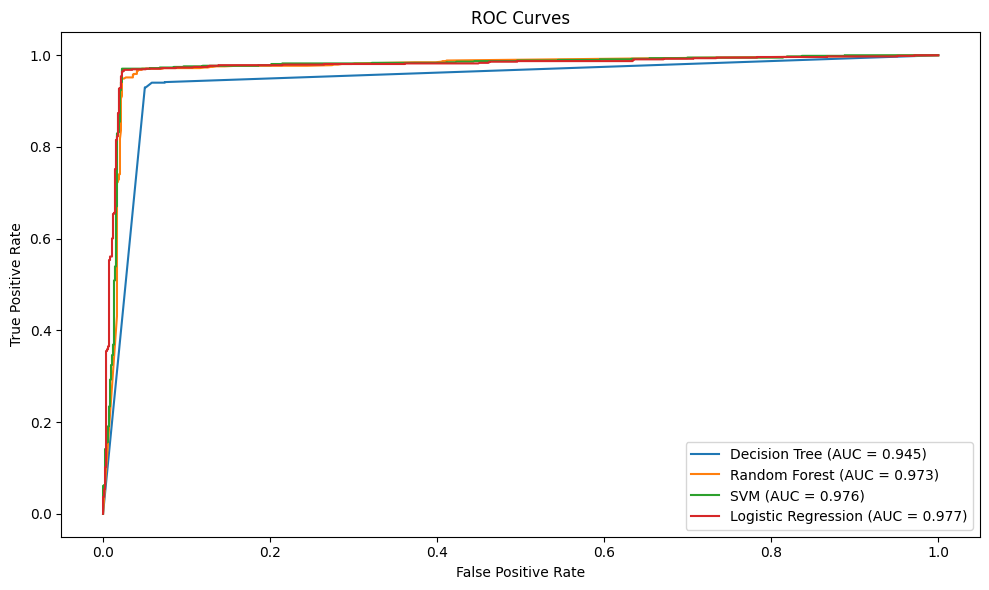

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
# remove some important features
# Drop all odor-related dummy variables
X_train_reduced = X_train.drop(
    columns=[col for col in X_train.columns if col.startswith('odor_')]
)

X_test_reduced = X_test.drop(
    columns=[col for col in X_test.columns if col.startswith('odor_')]
)
# Drop all spore-print-color dummy variables
X_train_reduced = X_train_reduced.drop(
    columns=[col for col in X_train_reduced.columns if col.startswith('spore-print-color_')]
)

X_test_reduced = X_test_reduced.drop(
    columns=[col for col in X_test_reduced.columns if col.startswith('spore-print-color_')]
)

plt.figure(figsize=(10, 6))

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
}

for name, model in models.items():
    model.fit(X_train_reduced, y_train)
    y_proba_reduced = model.predict_proba(X_test_reduced)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_reduced)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# random classifier baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

The features of odor and spore-print-color were identified as the most important features and removed. The resulting ROC curves actually showed a significant increase in AUC for the decision tree model, and slight increases to the AUC for the SVM and logistic regression models. The rnadom forest model had a slight decrease in AUC. \
The results are surprising since we would expect the removal of the most important features to lead to lower performance of the models (lower AUC). The increase could be due to overfitting of the original model, and information spread redundantly across the other features. Removing these features forces the tree to use the other features, which generalized better to the test set.